# Project — Chapter 88: Modeling Traffic Flow

> **Prerequisites:** ch062 (Piecewise), ch071 (Modeling), ch076 (Dynamical Systems)
>
> **Concepts:** Piecewise functions, conservation laws, discrete traffic CA model, shock waves
>
> **Output:** Cellular automaton traffic simulation with flow analysis
>
> **Difficulty:** Advanced | ~60 minutes

---

## Stage 1 — Fundamental Traffic Diagram

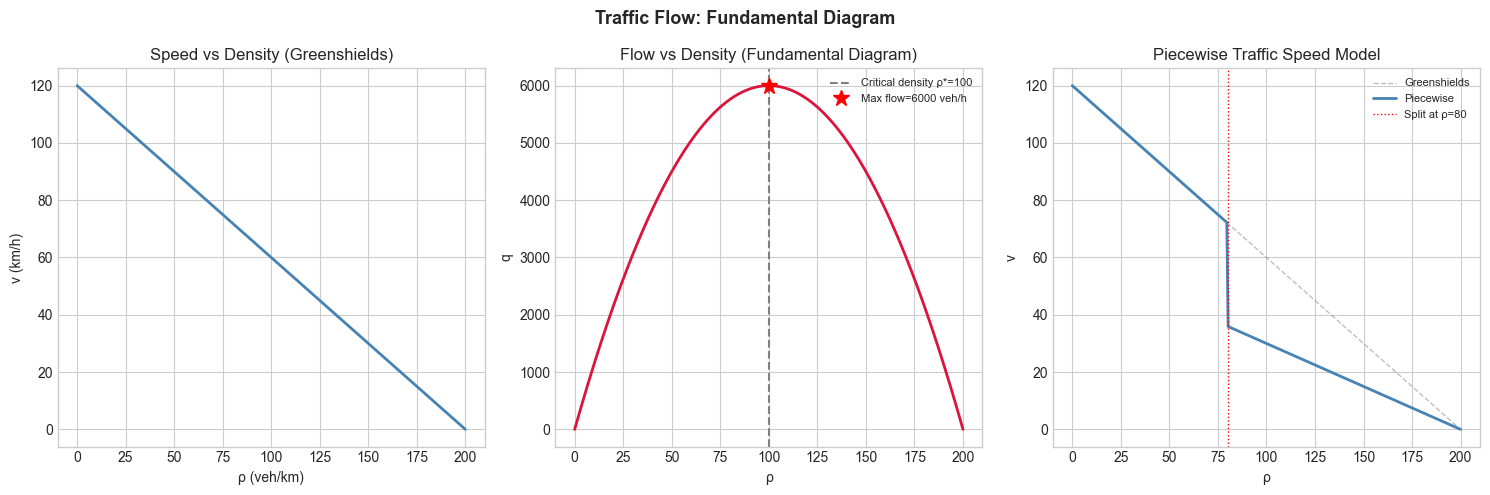

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

# Greenshields model: speed drops linearly with density
# v(rho) = v_max * (1 - rho/rho_max)
# flow q = rho * v = v_max * rho * (1 - rho/rho_max)

v_max = 120  # km/h
rho_max = 200  # vehicles/km

rho = np.linspace(0, rho_max, 300)
v = v_max * (1 - rho/rho_max)
q = rho * v  # flow (vehicles per hour)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].plot(rho, v, color='steelblue', linewidth=2)
axes[0].set_title('Speed vs Density (Greenshields)'); axes[0].set_xlabel('ρ (veh/km)'); axes[0].set_ylabel('v (km/h)')

axes[1].plot(rho, q, color='crimson', linewidth=2)
rho_crit = rho_max / 2
q_max = v_max * rho_max / 4
axes[1].axvline(rho_crit, color='gray', linestyle='--', label=f'Critical density ρ*={rho_crit:.0f}')
axes[1].plot(rho_crit, q_max, 'r*', markersize=12, label=f'Max flow={q_max:.0f} veh/h')
axes[1].set_title('Flow vs Density (Fundamental Diagram)'); axes[1].set_xlabel('ρ'); axes[1].set_ylabel('q')
axes[1].legend(fontsize=8)

# Piecewise: free-flow vs congested
rho_split = 80
v_free = lambda rho: v_max * (1 - rho/rho_max)
v_cong = lambda rho: v_max * 0.3 * (1 - (rho-rho_split)/(rho_max-rho_split))

v_pw = np.where(rho <= rho_split, v_free(rho), np.maximum(0, v_cong(rho)))
axes[2].plot(rho, v, color='gray', linewidth=1, linestyle='--', alpha=0.5, label='Greenshields')
axes[2].plot(rho, v_pw, color='steelblue', linewidth=2, label='Piecewise')
axes[2].axvline(rho_split, color='red', linewidth=1, linestyle=':', label=f'Split at ρ={rho_split}')
axes[2].set_title('Piecewise Traffic Speed Model'); axes[2].set_xlabel('ρ'); axes[2].set_ylabel('v'); axes[2].legend(fontsize=8)

plt.suptitle('Traffic Flow: Fundamental Diagram', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---

## Stage 2 — Cellular Automaton Traffic Simulation

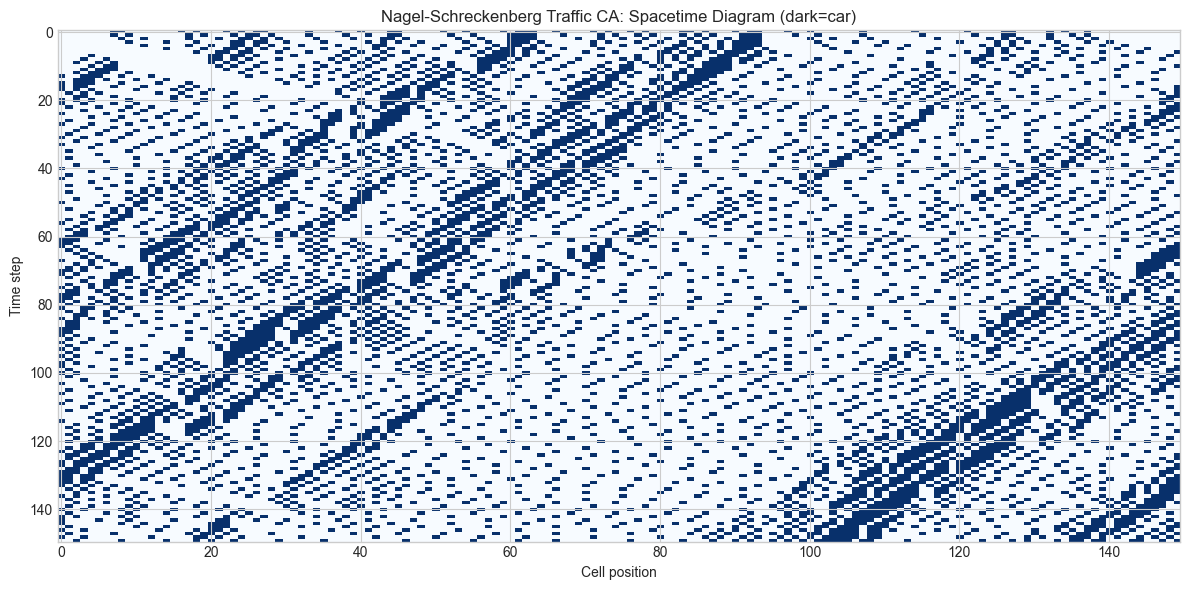

In [2]:
# Nagel-Schreckenberg model: 1D traffic CA
# Rules: 1) Accelerate, 2) Brake (collision avoidance), 3) Random slow-down, 4) Move

def nagel_schreckenberg(n_cells=100, n_cars=30, v_max=5, p_slow=0.3, n_steps=100, seed=0):
    np.random.seed(seed)
    road = np.full(n_cells, -1)  # -1 = empty
    car_positions = np.sort(np.random.choice(n_cells, n_cars, replace=False))
    velocities = np.zeros(n_cars, dtype=int)
    road[car_positions] = 0
    
    spacetime = []
    for step in range(n_steps):
        snapshot = (road >= 0).astype(int)
        spacetime.append(snapshot.copy())
        
        new_road = np.full(n_cells, -1)
        new_pos = car_positions.copy()
        
        for i, (pos, vel) in enumerate(zip(car_positions, velocities)):
            next_car = car_positions[(i+1) % n_cars]
            gap = (next_car - pos - 1) % n_cells
            
            vel = min(vel + 1, v_max)          # accelerate
            vel = min(vel, gap)                 # brake
            if np.random.random() < p_slow:     # random slow
                vel = max(vel - 1, 0)
            
            new_pos[i] = (pos + vel) % n_cells
            velocities[i] = vel
        
        car_positions = np.sort(new_pos)
        road = np.full(n_cells, -1)
        road[car_positions] = 1
    
    return np.array(spacetime)

spacetime = nagel_schreckenberg(n_cells=150, n_cars=40, n_steps=150)
fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(spacetime, cmap='Blues', aspect='auto', interpolation='nearest')
ax.set_title('Nagel-Schreckenberg Traffic CA: Spacetime Diagram (dark=car)')
ax.set_xlabel('Cell position'); ax.set_ylabel('Time step')
plt.tight_layout(); plt.show()

---

## Stage 3 — Shockwave Analysis

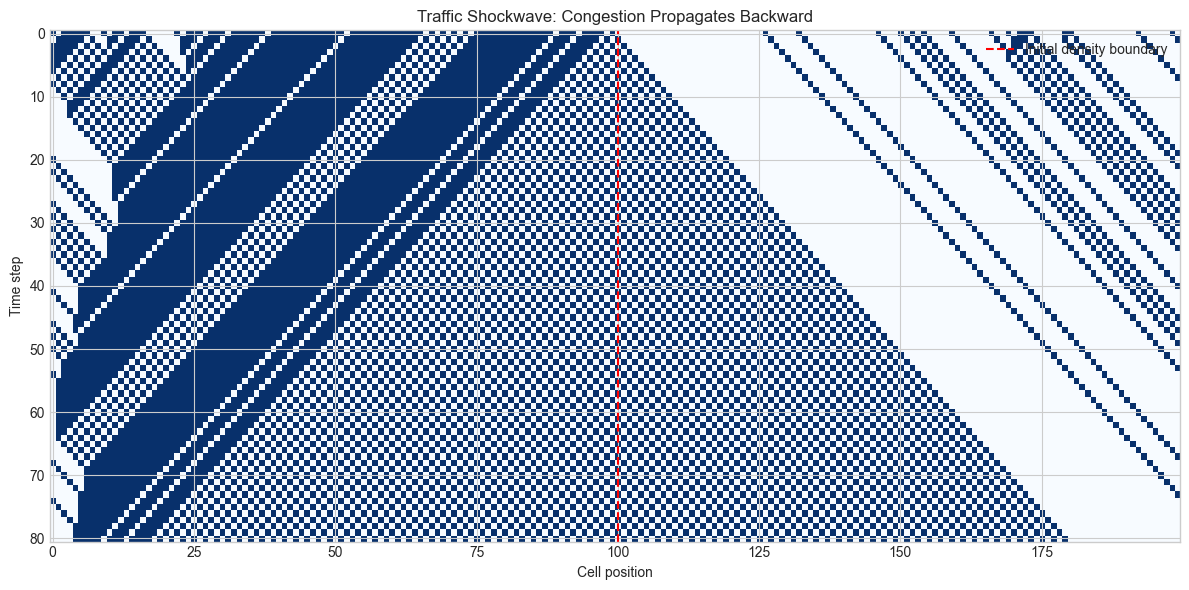

In [3]:
# Show how congestion waves propagate backward
# In traffic: jams travel backward even as cars move forward

# Simple shock: high density meets low density
n_cells, n_steps = 200, 80
density_left = 0.7   # high density (congestion)
density_right = 0.2  # free flow

# Initialize with step function in density
np.random.seed(0)
road_init = np.zeros(n_cells)
for i in range(n_cells):
    prob = density_left if i < n_cells//2 else density_right
    road_init[i] = 1 if np.random.random() < prob else 0

# Simple update: move cars right if next cell empty, else stay
spacetime_shock = [road_init.copy()]
road = road_init.copy()

for _ in range(n_steps):
    new_road = np.zeros_like(road)
    for i in range(n_cells):
        if road[i] == 1:
            next_cell = (i+1) % n_cells
            if road[next_cell] == 0:
                new_road[next_cell] = 1
            else:
                new_road[i] = 1
    road = new_road
    spacetime_shock.append(road.copy())

fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(spacetime_shock, cmap='Blues', aspect='auto')
ax.set_title('Traffic Shockwave: Congestion Propagates Backward')
ax.set_xlabel('Cell position'); ax.set_ylabel('Time step')
ax.axvline(n_cells//2, color='red', linewidth=1.5, linestyle='--', label='Initial density boundary')
ax.legend(); plt.tight_layout(); plt.show()

---

## Results & Reflection

**What was built:** Greenshields traffic model, piecewise speed model, Nagel-Schreckenberg CA simulation, and shockwave analysis.

**Extensions:** 1) Add on-ramps/off-ramps to the CA model. 2) Implement the LWR PDE traffic model numerically. 3) Estimate capacity of a road segment and optimal toll pricing.